# Final Project

**Group Name: Cat** \
**Yuki Matsushima (wlh858)**

## Table of Content
### 1. Danish House Prices
**1.1 Question 1: Danish Nominal House Price Growth** \
**1.2 Question 2: Danish Real House Price Growth** \
**1.3 Question 3: Danish Municipal House Price Growth and Initial Price Levels** \
**1.4 Question 4: Recovery of Municipal House Prices to the Pre-2008 Peak**

### 2. Exchange Economy
**2.1 Question 1: Demand and Excess Demand for Good 1** \
**2.2 Question 2: Tâtonnement Dynamics and Equilibrium Selection** \
**2.3 Question 3: Tâtonnement Convergence from Different Initial Prices** \
**2.4 Question 4: Dampened Newton-Raphson Equilibrium Mapping** \
**2.5 Question 5: Equilibrium Allocations in the Edgeworth Box**

### 3. The AS-AD Model
**3.1 Question 1: AD–SRAS Equilibrium** \
**3.2 Question 2: Temporary Demand Shock and Dynamic Adjustment** \
**3.3 Question 3: Persistent Stochastic Demand Shocks in the AS–AD Model**


In [1]:
# setup
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
from ExchangeEconomyModel import ExchangeEconomyModelClass
from ASADModel import ASADModelClass

## 1. Danish House Prices

### Question 1.1: Danish Norminal House Price Growth


In [2]:
BASE = "https://api.statbank.dk/v1"
url = f"{BASE}/tableinfo/EJ56"

r = requests.get(url, timeout=30)

info = r.json()

print(type(info["variables"]), len(info["variables"]))
print(info["variables"][0].keys())
print(info["variables"][0])


<class 'list'> 4
dict_keys(['id', 'text', 'elimination', 'time', 'map', 'values'])
{'id': 'OMRÅDE', 'text': 'område', 'elimination': True, 'time': False, 'map': 'Denmark_rural_07', 'values': [{'id': '000', 'text': 'Hele landet'}, {'id': '084', 'text': 'Region Hovedstaden'}, {'id': '01', 'text': 'Landsdel Byen København'}, {'id': '02', 'text': 'Landsdel Københavns omegn'}, {'id': '03', 'text': 'Landsdel Nordsjælland'}, {'id': '04', 'text': 'Landsdel Bornholm'}, {'id': '085', 'text': 'Region Sjælland'}, {'id': '05', 'text': 'Landsdel Østsjælland'}, {'id': '06', 'text': 'Landsdel Vest- og Sydsjælland'}, {'id': '083', 'text': 'Region Syddanmark'}, {'id': '07', 'text': 'Landsdel Fyn'}, {'id': '08', 'text': 'Landsdel Sydjylland'}, {'id': '082', 'text': 'Region Midtjylland'}, {'id': '09', 'text': 'Landsdel Østjylland'}, {'id': '10', 'text': 'Landsdel Vestjylland'}, {'id': '081', 'text': 'Region Nordjylland'}, {'id': '11', 'text': 'Landsdel Nordjylland'}]}


In [3]:
BASE = "https://api.statbank.dk/v1"

# tableinfo
info = requests.get(f"{BASE}/tableinfo/EJ56", timeout=30).json()

# helper: find a variable dict by its id
def get_var(var_id):
    return next(v for v in info["variables"] if v["id"] == var_id)

# helper: find a value id inside a variable by matching text
def find_value_id(var, contains_text):
    for x in var["values"]:
        if contains_text.lower() in x["text"].lower():
            return x["id"]
    raise ValueError(f"Could not find value containing '{contains_text}' in {var['id']}")

# regions: keep ONLY landsdele (provinces), not 'Hele landet' and not 'Region ...' 
omr = get_var("OMRÅDE")
landsdel_ids = [x["id"] for x in omr["values"] if x["text"].startswith("Landsdel")]
landsdel_texts = [x["text"] for x in omr["values"] if x["text"].startswith("Landsdel")]
print("Selected landsdele:", len(landsdel_ids), landsdel_texts[:5], "...")


Selected landsdele: 11 ['Landsdel Byen København', 'Landsdel Københavns omegn', 'Landsdel Nordsjælland', 'Landsdel Bornholm', 'Landsdel Østsjælland'] ...


In [4]:
[var["id"] for var in info["variables"]]


['OMRÅDE', 'EJENDOMSKATE', 'TAL', 'Tid']

In [5]:
def get_var(var_id):
    return next(v for v in info["variables"] if v["id"] == var_id)

def find_value_id(var, contains_text):
    for x in var["values"]:
        if contains_text.lower() in x["text"].lower():
            return x["id"]
    raise ValueError(f"Could not find value containing '{contains_text}' in {var['id']}")

ejk = get_var("EJENDOMSKATE")
tal = get_var("TAL")
tid = get_var("Tid")

# Print options so you can see the exact labels
print("EJENDOMSKATE options:")
for x in ejk["values"]:
    print(x["id"], "-", x["text"])

print("\nTAL options:")
for x in tal["values"]:
    print(x["id"], "-", x["text"])


EJENDOMSKATE options:
0111 - Enfamiliehuse
0801 - Sommerhuse
2103 - Ejerlejligheder, i alt

TAL options:
100 - Indeks
210 - Ændring i forhold til kvartalet før (pct.)
310 - Ændring i forhold til samme kvartal året før (pct.)


In [6]:
one_family_id = find_value_id(ejk, "Enfamilie")   # one-family houses
index_unit_id = find_value_id(tal, "Indeks")      # index

print("one_family_id =", one_family_id)
print("index_unit_id =", index_unit_id)


one_family_id = 0111
index_unit_id = 100


In [7]:
payload = {
    "table": "EJ56",
    "format": "CSV",
    "variables": [
        {"code": "OMRÅDE", "values": landsdel_ids},
        {"code": "EJENDOMSKATE", "values": ["0111"]},
        {"code": "TAL", "values": ["100"]},
        {"code": "Tid", "values": ["*"]}]}

r = requests.post("https://api.statbank.dk/v1/data", json=payload, timeout=60)


r.raise_for_status()

df = pd.read_csv(StringIO(r.text), sep=";")
df


,OMRÅDE,EJENDOMSKATE,TAL,TID,INDHOLD
0,Landsdel Byen København,Enfamiliehuse,Indeks,1992K1,"12,5"
1,Landsdel Byen København,Enfamiliehuse,Indeks,1992K2,"12,7"
2,Landsdel Byen København,Enfamiliehuse,Indeks,1992K3,"12,7"
3,Landsdel Byen København,Enfamiliehuse,Indeks,1992K4,"12,0"
4,Landsdel Byen København,Enfamiliehuse,Indeks,1993K1,"12,0"
...,...,...,...,...,...
1480,Landsdel Nordjylland,Enfamiliehuse,Indeks,2024K3,"100,2"
1481,Landsdel Nordjylland,Enfamiliehuse,Indeks,2024K4,"99,9"
1482,Landsdel Nordjylland,Enfamiliehuse,Indeks,2025K1,"100,9"
1483,Landsdel Nordjylland,Enfamiliehuse,Indeks,2025K2,"100,9"


In [8]:
# rename to easier english names
df = df.rename(columns={"OMRÅDE":"region","TID":"quarter","INDHOLD":"value"})

# convert Danish decimals "12,5" -> 12.5 and make numeric
df["value"] = (
    df["value"].astype(str)
      .str.replace(",", ".", regex=False))
df["value"] = pd.to_numeric(df["value"], errors="coerce")

# find regions with missing value
bad = df.groupby("region")["value"].apply(lambda s: s.isna().any())
drop_regions = bad[bad].index.tolist()

df_clean = df[~df["region"].isin(drop_regions)].copy()

print("Dropped regions (had missing):", drop_regions)
print("Remaining regions:", df_clean["region"].nunique())
df_clean.head()


Dropped regions (had missing): ['Landsdel Bornholm']
Remaining regions: 10


,region,EJENDOMSKATE,TAL,quarter,value
0,Landsdel Byen København,Enfamiliehuse,Indeks,1992K1,12.5
1,Landsdel Byen København,Enfamiliehuse,Indeks,1992K2,12.7
2,Landsdel Byen København,Enfamiliehuse,Indeks,1992K3,12.7
3,Landsdel Byen København,Enfamiliehuse,Indeks,1992K4,12.0
4,Landsdel Byen København,Enfamiliehuse,Indeks,1993K1,12.0


In [9]:
BASE_Q = "1992K1"

# base value per region at 1992K1
base = df_clean.loc[df_clean["quarter"] == BASE_Q, ["region", "value"]].set_index("region")["value"]

# create indexed series
df_clean["indexed"] = df_clean["value"] / df_clean["region"].map(base) * 100

df_clean.head()


,region,EJENDOMSKATE,TAL,quarter,value,indexed
0,Landsdel Byen København,Enfamiliehuse,Indeks,1992K1,12.5,100.0
1,Landsdel Byen København,Enfamiliehuse,Indeks,1992K2,12.7,101.6
2,Landsdel Byen København,Enfamiliehuse,Indeks,1992K3,12.7,101.6
3,Landsdel Byen København,Enfamiliehuse,Indeks,1992K4,12.0,96.0
4,Landsdel Byen København,Enfamiliehuse,Indeks,1993K1,12.0,96.0


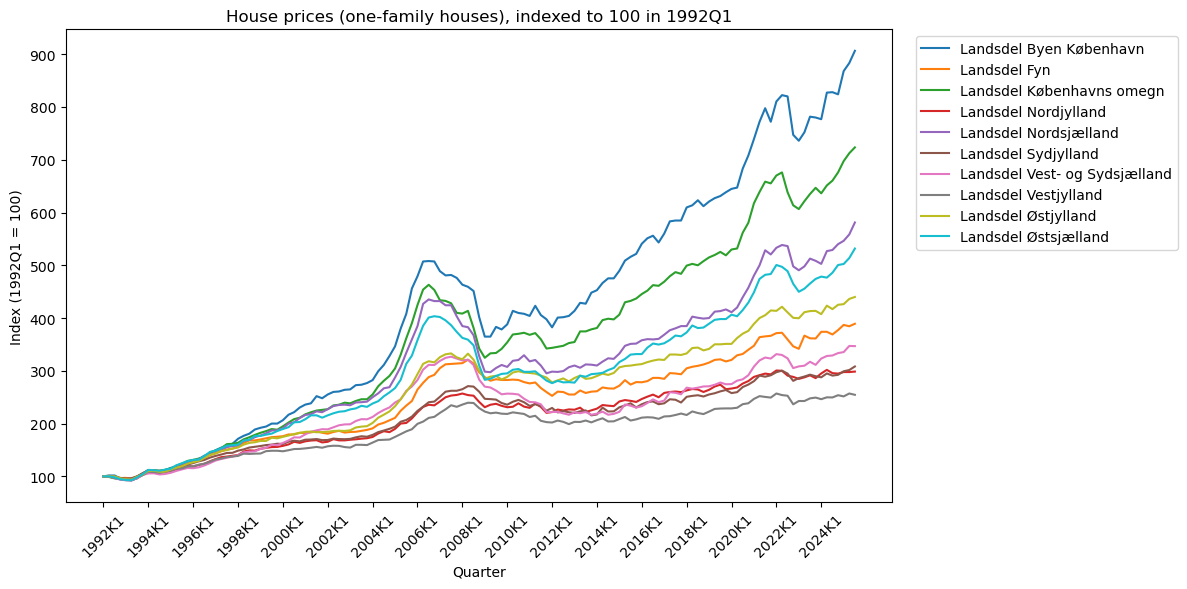

In [10]:
# make wide table: rows = quarter, cols = region, values = indexed
wide = df_clean.pivot(index="quarter", columns="region", values="indexed").sort_index()

plt.figure(figsize=(12,6))
for region in wide.columns:
    plt.plot(wide.index, wide[region], label=region)

plt.title("House prices (one-family houses), indexed to 100 in 1992Q1")
plt.xlabel("Quarter")
plt.ylabel("Index (1992Q1 = 100)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

step = 8
ticks = wide.index[::step]
plt.xticks(ticks, rotation=45)

plt.tight_layout()
plt.show()

In [11]:
# last available quarter
last_q = df_clean["quarter"].max()

growth = (
    df_clean[df_clean["quarter"] == last_q]
    .loc[:, ["region", "indexed"]]
    .sort_values("indexed", ascending=False)
    .reset_index(drop=True))

growth["pct_growth_since_1992"] = growth["indexed"] - 100
growth


,region,indexed,pct_growth_since_1992
0,Landsdel Byen København,906.400000,806.400000
1,Landsdel Københavns omegn,723.376623,623.376623
2,Landsdel Nordsjælland,581.052632,481.052632
3,Landsdel Østsjælland,531.707317,431.707317
4,Landsdel Østjylland,439.917695,339.917695
5,Landsdel Fyn,389.130435,289.130435
6,Landsdel Vest- og Sydsjælland,346.774194,246.774194
7,Landsdel Sydjylland,308.211144,208.211144
8,Landsdel Nordjylland,298.525074,198.525074
9,Landsdel Vestjylland,254.500000,154.500000


#### Question 1.1 Interpretation
The figure illustrates the development of house prices for one-family houses across Danish landsdele, indexed to 100 in 1992Q1. All regions display a similar cyclical pattern: a steady increase from the early 1990s, a sharp rise in the mid-2000s, a pronounced decline around the financial crisis, and a renewed period of strong growth in the later years. Despite these common movements, the long-run evolution of house prices differs substantially across regions.

House price growth is strongest in **Landsdel Byen København**, where the index reaches approximately **906.4** in the final quarter, corresponding to a total increase of about **806.4%** since 1992Q1. This reflects exceptionally strong and persistent growth in housing prices in the capital city. Surrounding areas such as **Landsdel Københavns omegn** also experience very high growth, with an index of roughly **723**, indicating substantial spillover effects from Copenhagen.

Moderate growth is observed in regions such as **Østsjælland** and **Østjylland**, where house price indices increase to around **532** and **440**, respectively. In contrast, more peripheral regions, particularly **Vestjylland** and **Nordjylland**, exhibit much weaker long-term growth. For example, **Vestjylland** reaches an index of approximately **255**, corresponding to an increase of about **155%** since 1992Q1.

Overall, the results reveal a clear pattern of **regional divergence** in Danish house prices over the past three decades. While house prices increase in all regions, growth has been heavily concentrated in and around Copenhagen, leading to a widening gap between the capital region and the rest of the country.



### Question 1.2: Danish Real House Price Growth

In [12]:
BASE = "https://api.statbank.dk/v1"

# pull metadata so you can see variable codes/values
meta = requests.get(f"{BASE}/tableinfo", params={"id": "PRIS113", "format": "JSON"}).json()
meta["variables"]  

[{'id': 'TYPE',
  'text': 'type',
  'elimination': True,
  'time': False,
  'values': [{'id': 'INDEKS', 'text': 'Forbrugerprisindeks'}]},
 {'id': 'Tid',
  'text': 'tid',
  'elimination': False,
  'time': True,
  'values': [{'id': '1980M01', 'text': '1980M01'},
   {'id': '1980M02', 'text': '1980M02'},
   {'id': '1980M03', 'text': '1980M03'},
   {'id': '1980M04', 'text': '1980M04'},
   {'id': '1980M05', 'text': '1980M05'},
   {'id': '1980M06', 'text': '1980M06'},
   {'id': '1980M07', 'text': '1980M07'},
   {'id': '1980M08', 'text': '1980M08'},
   {'id': '1980M09', 'text': '1980M09'},
   {'id': '1980M10', 'text': '1980M10'},
   {'id': '1980M11', 'text': '1980M11'},
   {'id': '1980M12', 'text': '1980M12'},
   {'id': '1981M01', 'text': '1981M01'},
   {'id': '1981M02', 'text': '1981M02'},
   {'id': '1981M03', 'text': '1981M03'},
   {'id': '1981M04', 'text': '1981M04'},
   {'id': '1981M05', 'text': '1981M05'},
   {'id': '1981M06', 'text': '1981M06'},
   {'id': '1981M07', 'text': '1981M07'},
 

In [13]:
# download monthly CPI (all types) from PRIS113
payload = {
    "table": "PRIS113",
    "format": "CSV",
    "variables": [
        {"code": "TYPE", "values": ["INDEKS"]},
        {"code": "Tid", "values": ["*"]},
    ],}

r = requests.post(f"{BASE}/data", json=payload)
r.raise_for_status()

cpi_raw = pd.read_csv(StringIO(r.text), sep=";")
cpi_raw


,TYPE,TID,INDHOLD
0,Forbrugerprisindeks,1980M01,"33,0"
1,Forbrugerprisindeks,1980M02,"33,3"
2,Forbrugerprisindeks,1980M03,"33,8"
3,Forbrugerprisindeks,1980M04,"34,0"
4,Forbrugerprisindeks,1980M05,"34,5"
...,...,...,...
547,Forbrugerprisindeks,2025M08,"121,7"
548,Forbrugerprisindeks,2025M09,"121,6"
549,Forbrugerprisindeks,2025M10,"122,1"
550,Forbrugerprisindeks,2025M11,"121,7"


In [14]:
cpi_raw.columns


Index(['TYPE', 'TID', 'INDHOLD'], dtype='object')

In [15]:
# Keep only what we need
cpi_m = cpi_raw[["TID", "INDHOLD"]].copy()

# Make INDHOLD numeric (handles comma decimals)
cpi_m["INDHOLD"] = (
    cpi_m["INDHOLD"]
    .astype(str)

    .str.replace(",", ".", regex=False))
cpi_m["INDHOLD"] = pd.to_numeric(cpi_m["INDHOLD"], errors="coerce")

# Convert time to datetime
cpi_m["date"] = pd.to_datetime(cpi_m["TID"].str.replace("M", "-"), format="%Y-%m")
cpi_m = cpi_m.sort_values("date").set_index("date")

# Monthly -> quarterly average CPI (use QE instead of Q)
cpi_q = cpi_m["INDHOLD"].resample("QE").mean().to_frame("CPI")

# Quarterly PeriodIndex like 1992Q1
cpi_q.index = cpi_q.index.to_period("Q")

cpi_q

,CPI
date,
1980Q1,33.366667
1980Q2,34.366667
1980Q3,35.333333
1980Q4,36.033333
1981Q1,36.966667
...,...
2024Q4,119.233333
2025Q1,120.200000
2025Q2,120.466667


In [16]:
# CPI quarterly index (PeriodIndex like 1980Q1) -> string like 1980K1
cpi_q2 = cpi_q.copy()
cpi_q2["quarter"] = cpi_q2.index.astype(str).str.replace("Q", "K", regex=False)

cpi_q2 = cpi_q2.reset_index(drop=True)[["quarter", "CPI"]]
cpi_q2.head()


,quarter,CPI
0,1980K1,33.366667
1,1980K2,34.366667
2,1980K3,35.333333
3,1980K4,36.033333
4,1981K1,36.966667


In [17]:
df_nom = df_clean[["region", "quarter", "value"]].copy()

df_nom = df_nom.merge(cpi_q2, on="quarter", how="left")

# sanity check: should be 0 missing CPI after merge
df_nom["CPI"].isna().mean()


np.float64(0.0)

In [18]:
BASE_Q = "1992K1"

# real price level (deflated by CPI)
df_nom["real_value"] = df_nom["value"] / df_nom["CPI"]

# re-index real prices to 100 in 1992K1 (by region)
real_base = (
    df_nom.loc[df_nom["quarter"] == BASE_Q, ["region", "real_value"]]
    .set_index("region")["real_value"])

df_nom["real_indexed"] = df_nom["real_value"] / df_nom["region"].map(real_base) * 100

df_nom.head()


,region,quarter,value,CPI,real_value,real_indexed
0,Landsdel Byen København,1992K1,12.5,63.966667,0.195414,100.000000
1,Landsdel Byen København,1992K2,12.7,64.633333,0.196493,100.552037
2,Landsdel Byen København,1992K3,12.7,64.633333,0.196493,100.552037
3,Landsdel Byen København,1992K4,12.0,64.800000,0.185185,94.765432
4,Landsdel Byen København,1993K1,12.0,64.766667,0.185280,94.814205


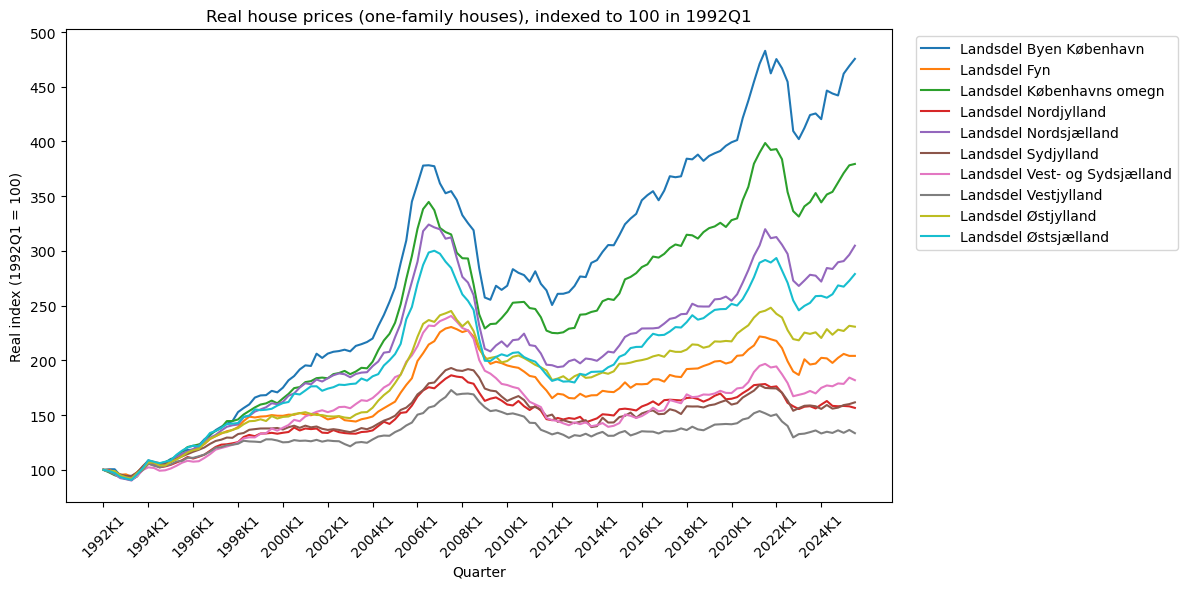

In [19]:
wide_real = (
    df_nom.pivot(index="quarter", columns="region", values="real_indexed")
    .sort_index())

plt.figure(figsize=(12, 6))
for region in wide_real.columns:
    plt.plot(wide_real.index, wide_real[region], label=region)

plt.title("Real house prices (one-family houses), indexed to 100 in 1992Q1")
plt.xlabel("Quarter")
plt.ylabel("Real index (1992Q1 = 100)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

step = 8
ticks = wide_real.index[::step]
plt.xticks(ticks, rotation=45)

plt.tight_layout()
plt.show()


#### Question 1.2 Interpretation

Deflating nominal house prices by the Consumer Price Index (CPI) lowers the measured growth across all provinces, meaning that part of the increase in the nominal house price indices in Question 1.1 is explained by general inflation rather than a pure rise in housing purchasing-power value.

Even after adjusting for inflation, real house prices still increase substantially over the sample period, but the real series are visibly “flatter” than the nominal ones, especially in periods where CPI rises faster. This implies that some of the strong nominal appreciation in the later parts of the sample reflects broader price-level increases, not only housing-specific demand/supply dynamics.

The relative ordering across provinces is broadly preserved: provinces that were top performers in nominal terms remain among the strongest in real terms, while weaker nominal-growth provinces also remain comparatively weaker after deflation. In other words, inflation adjustment changes the *levels* and *magnitudes* of growth, but it does not fundamentally change which provinces experienced the strongest vs. weakest long-run housing market appreciation.

Overall, the real house price plot confirms that long-run house price growth in Denmark is not solely an inflation story (housing became more expensive in real terms across most provinces) while also showing that comparing provinces using nominal indices can overstate the true increase in housing values when inflation is rising.


### Question 1.3: Danish Municipal House Price Growth and Initial Price Levels

In [20]:
q13_path_excel = "BM010_houses.xlsx"
q13_raw = pd.read_excel(q13_path_excel)

# Fix headers/structure 
# The quarter labels starting from column index 3
quarters = q13_raw.iloc[1, 3:].tolist()

# Municipality names starting from row index 2
municipalities = q13_raw.iloc[2:, 2].tolist()

# The actual price data starts at row index 2 and column index 3
prices = q13_raw.iloc[2:, 3:].copy()

# Set correct columns + insert municipality as first column
prices.columns = quarters
prices.insert(0, "municipality", municipalities)

# Overwrite q13_raw with the cleaned version
q13_raw = prices.reset_index(drop=True)

print("q13_raw shape:", q13_raw.shape)
print("q13_raw columns:", list(q13_raw.columns))
q13_raw

q13_raw shape: (98, 135)
q13_raw columns: ['municipality', '1992Q1', '1992Q2', '1992Q3', '1992Q4', '1993Q1', '1993Q2', '1993Q3', '1993Q4', '1994Q1', '1994Q2', '1994Q3', '1994Q4', '1995Q1', '1995Q2', '1995Q3', '1995Q4', '1996Q1', '1996Q2', '1996Q3', '1996Q4', '1997Q1', '1997Q2', '1997Q3', '1997Q4', '1998Q1', '1998Q2', '1998Q3', '1998Q4', '1999Q1', '1999Q2', '1999Q3', '1999Q4', '2000Q1', '2000Q2', '2000Q3', '2000Q4', '2001Q1', '2001Q2', '2001Q3', '2001Q4', '2002Q1', '2002Q2', '2002Q3', '2002Q4', '2003Q1', '2003Q2', '2003Q3', '2003Q4', '2004Q1', '2004Q2', '2004Q3', '2004Q4', '2005Q1', '2005Q2', '2005Q3', '2005Q4', '2006Q1', '2006Q2', '2006Q3', '2006Q4', '2007Q1', '2007Q2', '2007Q3', '2007Q4', '2008Q1', '2008Q2', '2008Q3', '2008Q4', '2009Q1', '2009Q2', '2009Q3', '2009Q4', '2010Q1', '2010Q2', '2010Q3', '2010Q4', '2011Q1', '2011Q2', '2011Q3', '2011Q4', '2012Q1', '2012Q2', '2012Q3', '2012Q4', '2013Q1', '2013Q2', '2013Q3', '2013Q4', '2014Q1', '2014Q2', '2014Q3', '2014Q4', '2015Q1', '2015Q2', '

,municipality,1992Q1,1992Q2,1992Q3,1992Q4,1993Q1,1993Q2,1993Q3,1993Q4,1994Q1,...,2023Q1,2023Q2,2023Q3,2023Q4,2024Q1,2024Q2,2024Q3,2024Q4,2025Q1,2025Q2
0,København,5355,5451,5374,5171,5068,5186,5609,5519,5503,...,43538,46023,47651,48146,47769,51843,52011,54143,56588,56744
1,Frederiksberg,5183,5626,6980,6686,5537,7047,6651,6174,6558,...,67716,67981,69455,72835,69100,75199,79964,79804,82363,..
2,Dragør,6251,6472,6364,6246,6158,6438,6573,6261,5969,...,33809,33105,35803,33492,34092,35732,41012,36296,36214,40602
3,Tårnby,5747,6003,6075,5856,5275,5860,5976,5916,6196,...,30923,31249,33712,34524,32718,35569,34602,35882,36194,37924
4,Albertslund,5240,5408,5417,5341,5130,4773,5746,5492,5616,...,23417,23360,23703,24200,23486,24548,24941,26787,25764,26737
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,Morsø,2706,2754,2702,2571,2607,2794,2791,2571,2694,...,4780,5579,5269,5905,6032,6385,6674,5212,7769,5219
94,Rebild,3040,2901,2845,2772,2710,2881,3066,3208,3093,...,10546,10790,10749,10225,12371,11248,12136,10498,12015,11978
95,Thisted,2750,2646,2597,2485,2874,2956,3038,3252,3074,...,7059,6644,7061,6512,7136,8003,8090,8114,7435,7847
96,Vesthimmerlands,2802,2587,2529,2730,2766,2764,2924,2964,3262,...,7034,6347,6749,6767,5913,6758,7203,6605,7232,7225


In [21]:
# quarter columns (everything except municipality)
q13_quarter_cols = [c for c in q13_raw.columns if c != "municipality"]
q13_fixed = q13_raw.copy()

# replace ".." with NaN without the downcasting warning
q13_fixed[q13_quarter_cols] = q13_fixed[q13_quarter_cols].mask(q13_fixed[q13_quarter_cols].eq(".."), np.nan)

# convert to numeric
q13_fixed[q13_quarter_cols] = q13_fixed[q13_quarter_cols].apply(pd.to_numeric, errors="coerce")

print("Missing cells:", int(q13_fixed[q13_quarter_cols].isna().sum().sum()))

Missing cells: 145


In [22]:
q13_clean = q13_fixed.loc[~q13_fixed[q13_quarter_cols].isna().any(axis=1)].copy()

print("Before:", q13_fixed.shape)
print("After :", q13_clean.shape)
print("Remaining missing:", int(q13_clean[q13_quarter_cols].isna().sum().sum()))

Before: (98, 135)
After : (92, 135)
Remaining missing: 0


In [23]:
# identify first and last quarter in the data (based on column order)
q13_first_q = q13_quarter_cols[0]
q13_last_q  = q13_quarter_cols[-1]

print("First quarter:", q13_first_q)
print("Last quarter :", q13_last_q)

# build municipality-level summary
q13_summary = pd.DataFrame({
    "municipality": q13_clean["municipality"],
    "initial_price": q13_clean[q13_first_q],
    "final_price": q13_clean[q13_last_q],})

q13_summary["total_growth"] = q13_summary["final_price"] - q13_summary["initial_price"]
q13_summary.head()


First quarter: 1992Q1
Last quarter : 2025Q2


,municipality,initial_price,final_price,total_growth
0,København,5355.0,56744.0,51389.0
2,Dragør,6251.0,40602.0,34351.0
3,Tårnby,5747.0,37924.0,32177.0
4,Albertslund,5240.0,26737.0,21497.0
5,Ballerup,5696.0,35127.0,29431.0


In [24]:
corr_init_growth = q13_summary["initial_price"].corr(q13_summary["total_growth"])
corr_init_growth

np.float64(0.900647532242277)

In [25]:
top5_growth = q13_summary.nlargest(5, "total_growth")
top5_initial = q13_summary.nlargest(5, "initial_price")

top5_growth, top5_initial


(      municipality  initial_price  final_price  total_growth
 7         Gentofte         6783.0      61358.0       54575.0
 0        København         5355.0      56744.0       51389.0
 14  Lyngby-Taarbæk         6937.0      52627.0       45690.0
 27       Rudersdal         7295.0      47227.0       39932.0
 8         Gladsaxe         6157.0      44819.0       38662.0,
       municipality  initial_price  final_price  total_growth
 16      Vallensbæk         7820.0      30440.0       22620.0
 26        Hørsholm         7363.0      40719.0       33356.0
 27       Rudersdal         7295.0      47227.0       39932.0
 14  Lyngby-Taarbæk         6937.0      52627.0       45690.0
 7         Gentofte         6783.0      61358.0       54575.0)

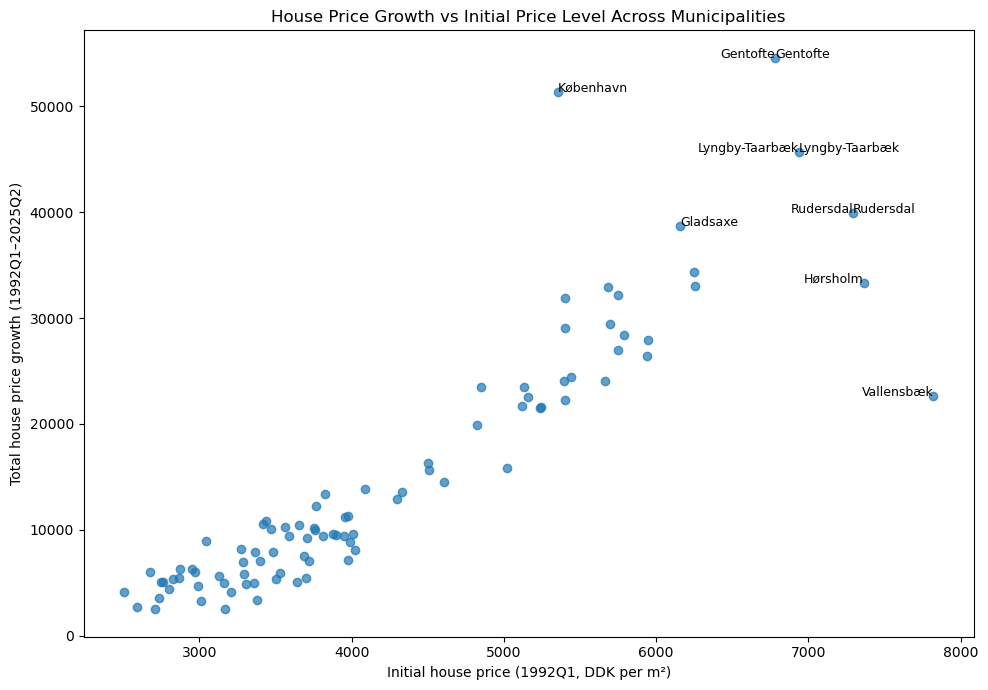

In [26]:
plt.figure(figsize=(10, 7))

# scatter
plt.scatter(
    q13_summary["initial_price"],
    q13_summary["total_growth"],
    alpha=0.7)

plt.xlabel("Initial house price (1992Q1, DDK per m²)")
plt.ylabel("Total house price growth (1992Q1–2025Q2)")
plt.title("House Price Growth vs Initial Price Level Across Municipalities")

# label top 5 growth
for _, row in top5_growth.iterrows():
    plt.text(
        row["initial_price"],
        row["total_growth"],
        row["municipality"],
        fontsize=9,
        ha="left")

# label top 5 initial price
for _, row in top5_initial.iterrows():
    plt.text(
        row["initial_price"],
        row["total_growth"],
        row["municipality"],
        fontsize=9,
        ha="right")

plt.tight_layout()
plt.show()


#### Question 1.3 Interpretation
The scatter plot of **total house price growth** (2025Q2 − 1992Q1, DDK per m²) against the **initial house price level** (1992Q1) shows a **strong positive relationship**. The correlation between the initial level and total growth is **0.9006**, implying that municipalities that started out more expensive in 1992 generally experienced **larger absolute price increases** over the full sample period.

The **five municipalities with the highest total growth** are:
- **Gentofte** (+54,575 DDK per m²)
- **København** (+51,389 DDK per m²)
- **Lyngby-Taarbæk** (+45,690 DDK per m²)
- **Rudersdal** (+39,932 DDK per m²)
- **Gladsaxe** (+38,662 DDK per m²)

The **five municipalities with the highest initial price levels (1992Q1)** are:
- **Vallensbæk** (7,820 DDK per m²)
- **Hørsholm** (7,363 DDK per m²)
- **Rudersdal** (7,295 DDK per m²)
- **Lyngby-Taarbæk** (6,937 DDK per m²)
- **Gentofte** (6,783 DDK per m²)

Overall, the pattern suggests **divergence** rather than convergence: municipalities with initially high price levels (largely in and around Copenhagen) also tended to have the largest total increases over time.


### Question 1.4: Recovery of Municipal House Prices to the Pre-2008 Peak

In [27]:
# long format + 4-quarter backward-looking rolling average
q13_quarter_cols = [c for c in q13_clean.columns if c != "municipality"]

q14_long = q13_clean.melt(
    id_vars="municipality",
    value_vars=q13_quarter_cols,
    var_name="quarter",
    value_name="price_m2")

# sort
q14_long = q14_long.sort_values(["municipality","quarter"]).reset_index(drop=True)

# 4-quarter backward-looking rolling mean within each municipality
q14_long["roll4"] = (
    q14_long.groupby("municipality")["price_m2"]
            .transform(lambda s: s.rolling(window=4, min_periods=4).mean()))

q14_long.head(12)


,municipality,quarter,price_m2,roll4
0,Aabenraa,1992Q1,3356.0,NaN
1,Aabenraa,1992Q2,3277.0,NaN
2,Aabenraa,1992Q3,3079.0,NaN
3,Aabenraa,1992Q4,3178.0,3222.50
4,Aabenraa,1993Q1,3306.0,3210.00
5,Aabenraa,1993Q2,3372.0,3233.75
6,Aabenraa,1993Q3,3337.0,3298.25
7,Aabenraa,1993Q4,3385.0,3350.00
8,Aabenraa,1994Q1,3665.0,3439.75
9,Aabenraa,1994Q2,3592.0,3494.75


In [28]:
# find each municipality's pre-2008 peak of the rolling average

pre_crisis = q14_long[q14_long["quarter"] <= "2008Q2"].copy()

peak_pre2008 = (
    pre_crisis.groupby("municipality")["roll4"]
              .max()
              .reset_index()
              .rename(columns={"roll4": "peak_roll4_pre2008"}))

peak_pre2008.head()


,municipality,peak_roll4_pre2008
0,Aabenraa,7520.00
1,Aalborg,11713.75
2,Albertslund,20976.50
3,Allerød,25055.75
4,Assens,8691.25


In [29]:
# compare pre　2008 peak to latest rolling average

latest_roll4 = (
    q14_long.dropna(subset=["roll4"])
            .groupby("municipality")["roll4"]
            .last()
            .reset_index()
            .rename(columns={"roll4": "latest_roll4"}))

q14_compare = peak_pre2008.merge(latest_roll4, on="municipality", how="inner")
q14_compare["gap_from_peak"] = q14_compare["latest_roll4"] - q14_compare["peak_roll4_pre2008"]

# municipalities still below peak
below_peak = q14_compare[q14_compare["gap_from_peak"] < 0].sort_values("gap_from_peak")

below_peak.head(10)


,municipality,peak_roll4_pre2008,latest_roll4,gap_from_peak
90,Vordingborg,10926.50,9011.50,-1915.00
76,Stevns,14803.25,13149.00,-1654.25
51,Lolland,6304.50,4953.50,-1351.00
48,Langeland,7334.75,6019.00,-1315.75
27,Halsnæs,17904.75,16621.00,-1283.75
56,Norddjurs,8354.00,7130.50,-1223.50
62,Odsherred,11473.00,10305.50,-1167.50
77,Struer,8348.75,7282.00,-1066.75
26,Haderslev,8482.50,7605.00,-877.50
25,Guldborgsund,8589.25,7774.25,-815.00


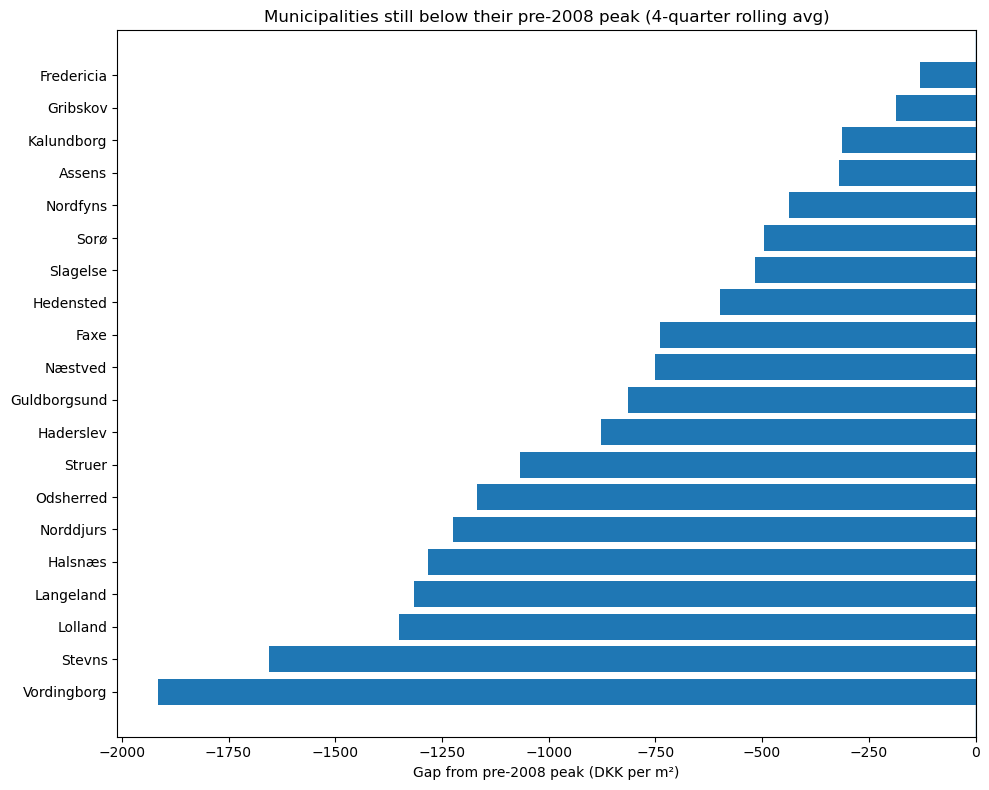

In [30]:
# take the municipalities still below peak, sorted
plot_df = below_peak.copy()

plt.figure(figsize=(10, 8))
plt.barh(plot_df["municipality"], plot_df["gap_from_peak"])
plt.axvline(0, linewidth=1)
plt.title("Municipalities still below their pre-2008 peak (4-quarter rolling avg)")
plt.xlabel("Gap from pre-2008 peak (DKK per m²)")
plt.ylabel("")
plt.tight_layout()
plt.show()

#### Question 1.4 Interpretation
Using the four-quarter backward-looking rolling average of house prices per m², we compare each municipality’s **pre-2008 peak** (measured up to **2008Q2**) to the **latest available** rolling average. A municipality is classified as **not recovered** if the latest rolling average remains **below** its pre-2008 peak (i.e., the gap is negative).

The results show that a **non-trivial set of municipalities** are still below their pre-crisis peak levels even in the most recent data. The bar chart highlights both **which municipalities** have not recovered and **how large** the shortfall is. The largest gaps are found in:

- **Vordingborg**: peak ≈ **10,926.5** vs latest ≈ **9,011.5** → gap ≈ **−1,915 DKK/m²**
- **Stevns**: peak ≈ **14,803.25** vs latest ≈ **13,149.00** → gap ≈ **−1,654 DKK/m²**
- **Lolland**: peak ≈ **6,304.50** vs latest ≈ **4,953.50** → gap ≈ **−1,351 DKK/m²**
- **Langeland**: peak ≈ **7,334.75** vs latest ≈ **6,019.00** → gap ≈ **−1,316 DKK/m²**

Several additional municipalities remain below peak, though with smaller gaps (e.g., **Halsnæs, Norddjurs, Odsherred, Struer, Haderslev, Guldborgsund**, etc.), typically ranging from a few hundred to just over one thousand DKK per m² below their pre-2008 peak.

Overall, the pattern suggests that the housing market recovery has been **uneven across Denmark**: while many municipalities have reached or surpassed their pre-2008 peak, a group of (often more peripheral) municipalities still show **persistent shortfalls** relative to bubble-era peak price levels.


---

## 2 Exchange Economy

### Question 2.1: Demand and Excess Demand for Good 1

In [31]:
model = ExchangeEconomyModelClass()

# grid for p1
p1_grid = np.linspace(0.25, 5.0, 100)

# containers
x1A = np.empty_like(p1_grid)
x1B = np.empty_like(p1_grid)
eps1 = np.empty_like(p1_grid)

# compute demands + excess demand on the grid
for i, p1 in enumerate(p1_grid):
    x1A[i] = model.demand_A(p1)[0]                 # good 1 demand by A
    x1B[i] = model.demand_B(p1)[0]                 # good 1 demand by B
    eps1[i] = model.check_market_clearing(p1)[0]   # excess demand for good 1

# ---- Find approximate equilibria (where eps1 ≈ 0) ----
# (1) sign changes between consecutive points => root in between
sign_change_idx = np.where(np.sign(eps1[:-1]) * np.sign(eps1[1:]) < 0)[0]

# (2) linear interpolation to get approximate p1* for each sign-change interval
p1_star_approx = []
for j in sign_change_idx:
    pL, pR = p1_grid[j], p1_grid[j+1]
    eL, eR = eps1[j], eps1[j+1]
    p_star = pL - eL * (pR - pL) / (eR - eL)   # linearly interpolate root
    p1_star_approx.append(p_star)

p1_star_approx = np.array(p1_star_approx)

print("Approx. equilibrium prices (from zero-crossings):", p1_star_approx)
print("Number of equilibria found on the grid:", len(p1_star_approx))

Approx. equilibrium prices (from zero-crossings): [0.42525735 1.00052541 2.37027593]
Number of equilibria found on the grid: 3


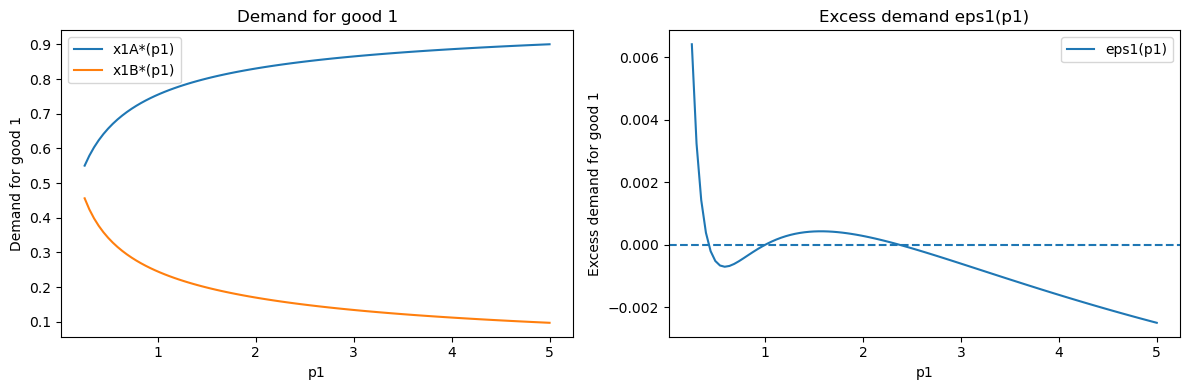

In [32]:
# Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# 1. demands for good 1
ax[0].plot(p1_grid, x1A, label="x1A*(p1)")
ax[0].plot(p1_grid, x1B, label="x1B*(p1)")
ax[0].set_xlabel("p1")
ax[0].set_ylabel("Demand for good 1")
ax[0].set_title("Demand for good 1")
ax[0].legend()

# 2. excess demand for good 1
ax[1].plot(p1_grid, eps1, label="eps1(p1)")
ax[1].axhline(0, linestyle="--")
ax[1].set_xlabel("p1")
ax[1].set_ylabel("Excess demand for good 1")
ax[1].set_title("Excess demand eps1(p1)")
ax[1].legend()

plt.tight_layout()
plt.show()


#### Question 2.1 Interpretation

The left panel shows the individual demand for good 1 by consumers A and B as functions of the relative price $p_1$. Consumer A’s demand for good 1 is increasing in $p_1$, while consumer B’s demand is decreasing. This asymmetric behavior reflects the extreme endowment structure of the economy, where consumer A is almost fully endowed with good 1, whereas consumer B holds almost none. As a result, increases in $p_1$ raise consumer A’s income substantially, strengthening their demand for good 1, while making good 1 relatively more expensive for consumer B.

The right panel plots the excess demand for good 1, defined as total demand minus total supply, $\varepsilon_1(p_1) = x_1^A(p_1) + x_1^B(p_1) - 1$. The excess demand function is non-monotonic and crosses zero three times within the considered price range. These zero crossings correspond to three Walrasian equilibrium prices, which occur approximately at $p_1 \approx 0.43$, $p_1 \approx 1.00$, and $p_1 \approx 2.37$.

The presence of multiple equilibrium prices indicates that the exchange economy admits multiple market-clearing outcomes. This multiplicity arises from the combination of CES preferences and highly unequal initial endowments, which generate strong income effects and non-standard demand responses. The non-monotonic shape of the excess demand function suggests that different price adjustment processes may converge to different equilibria, motivating the numerical analysis of equilibrium selection in the subsequent questions.


### Question 2.2: Tâtonnement Dynamics and Equilibrium Selection


In [33]:
# 1. initialize
p1_0 = 0.9
k = 0

# store sequences for plotting
p_path = [p1_0]
eps_path = [] 

In [34]:
# 2. compute excess demand at current price
p1_k = p_path[-1]  # current p1^k

eps_k, _ = model.check_market_clearing(p1_k)  # eps_k is excess demand for good 1
eps_path.append(eps_k)

In [35]:
# 3. stoppage rule
tau = 1e-8

if abs(eps_k) < tau:
    p1_star = p1_k
    print(f"Converged: p1* = {p1_star:.10f}, eps = {eps_k:.2e}, iterations = {len(eps_path)-1}")


In [36]:
# 4: max iteration safeguard
K = 5000

if k > K:
    raise RuntimeError("Tatonnement did not converge within K iterations.")

In [37]:
# 5. price update
nu = 50

p1_next = p1_k + nu * eps_k
p_path.append(p1_next)

# increment iteration counter
k += 1

In [38]:
def tatonnement(p1_0, model, tau=1e-8, nu=50, K=5000):

    k = 0
    p_path = [p1_0]
    eps_path = []

    while True:
        # Part 2: compute excess demand
        p1_k = p_path[-1]
        eps_k, _ = model.check_market_clearing(p1_k)
        eps_path.append(eps_k)

        # Part 3: stopping rule
        if abs(eps_k) < tau:
            return p_path, eps_path

        # Part 4: max iterations
        if k > K:
            raise RuntimeError("Tâtonnement did not converge")

        # Part 5: price update
        p1_next = p1_k + nu * eps_k
        p_path.append(p1_next)

        # Part 6: increment
        k += 1

In [39]:
# first guess with p1_0 = 0.9
p_path_09, eps_path_09 = tatonnement(0.9, model)

print("p1* =", p_path_09[-1])
print("last eps =", eps_path_09[-1])
print("iterations =", len(eps_path_09)-1)


p1* = 0.42187627669863426
last eps = -8.178701604855121e-09
iterations = 33


In [40]:
# second guess with p1_0 = 1.1
p_path_11, eps_path_11 = tatonnement(1.1, model)

print("p1* =", p_path_11[-1])
print("last eps =", eps_path_11[-1])
print("iterations =", len(eps_path_11)-1)

p1* = 2.3703561473576165
last eps = 9.568506931234566e-09
iterations = 291


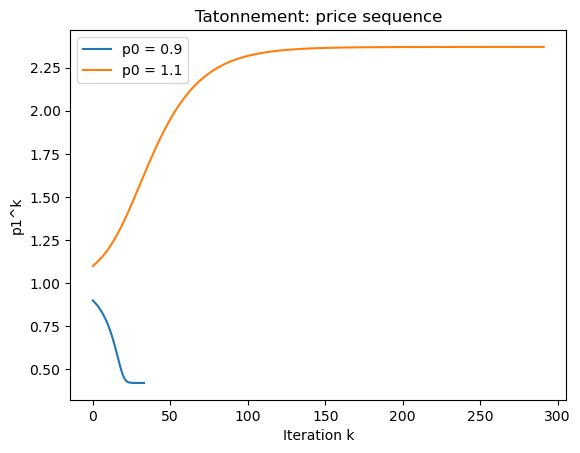

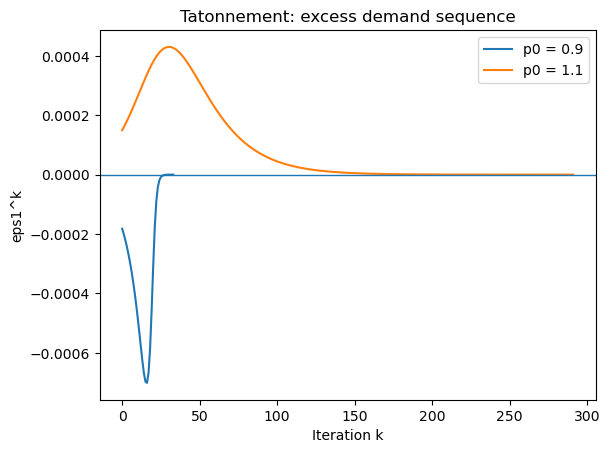

In [41]:
# Plot p^k paths
plt.figure()
plt.plot(p_path_09, label="p0 = 0.9")
plt.plot(p_path_11, label="p0 = 1.1")
plt.xlabel("Iteration k")
plt.ylabel("p1^k")
plt.title("Tatonnement: price sequence")
plt.legend()
plt.show()

# Plot eps^k paths
plt.figure()
plt.plot(eps_path_09, label="p0 = 0.9")
plt.plot(eps_path_11, label="p0 = 1.1")
plt.axhline(0, linewidth=1)
plt.xlabel("Iteration k")
plt.ylabel("eps1^k")
plt.title("Tatonnement: excess demand sequence")
plt.legend()
plt.show()


#### Question 2.2 Interpretation
The tatonnement algorithm converges in both cases, as the excess demand for good 1, $\varepsilon_1^k$, falls below the tolerance level $\tau = 10^{-8}$. However, the **equilibrium price reached and the speed of convergence depend on the initial price guess**, highlighting the existence of multiple equilibria in the exchange economy.

When the initial price is set to $p_1^0 = 0.9$, the algorithm converges quickly to a **low-price equilibrium** at $p_1^* \approx 0.42$ after 33 iterations. Along this path, excess demand is initially negative, which leads to downward price adjustments until market clearing is achieved. In contrast, starting from $p_1^0 = 1.1$ results in convergence to a **high-price equilibrium** at $p_1^* \approx 2.37$, but requires substantially more iterations (291). In this case, excess demand is initially positive, causing prices to adjust upward before gradually approaching equilibrium.

The difference in convergence speed reflects the shape of the excess demand function around each equilibrium. Near the low-price equilibrium, excess demand reacts strongly to price changes, leading to faster convergence. Around the high-price equilibrium, excess demand is flatter, so price adjustments are smaller and convergence is slower.

**Answer to the question:** Yes, the choice of the initial price guess determines which equilibrium is found. This occurs because the economy features multiple locally stable equilibria, and the tâtonnement algorithm converges to the equilibrium that lies within the basin of attraction of the initial price.



### Question 2.3: Tâtonnement Convergence from Different Initial Prices

In [42]:
p1_grid = np.linspace(0.25, 5, 50)

In [43]:
p1_star_list = []
converged = []
iters = [] # iteration

for p1_0 in p1_grid:
    try:
        p_path, eps_path = tatonnement(p1_0, model, tau=1e-8, nu=50, K=5000)
        p1_star_list.append(p_path[-1])
        converged.append(True)
        iters.append(len(eps_path))  # number of eps evaluations (iterations)
    except RuntimeError:
        p1_star_list.append(np.nan)
        converged.append(False)
        iters.append(np.nan)

p1_star_list = np.array(p1_star_list)
converged = np.array(converged)

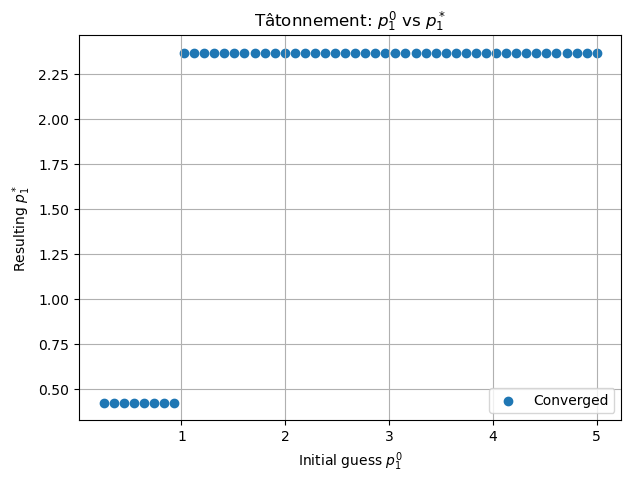

In [44]:
plt.figure(figsize=(7,5))

# show converged points
plt.scatter(p1_grid[converged], p1_star_list[converged], label="Converged")

# show failed points (if any)
if np.any(~converged):
    plt.scatter(p1_grid[~converged], p1_star_list[~converged], label="Failed")

plt.xlabel("Initial guess $p_1^0$")
plt.ylabel("Resulting $p_1^*$")
plt.title("Tâtonnement: $p_1^0$ vs $p_1^*$")
plt.grid(True)
plt.legend()
plt.show()


In [45]:
# round to see distinct equilibria clearly
eq_candidates = np.unique(np.round(p1_star_list[converged], 4))
eq_candidates


array([0.4219, 2.3704])

In [46]:
for p in eq_candidates:
    eps1, eps2 = model.check_market_clearing(p)
    print(f"p1 = {p:.5f} | eps1 = {eps1:.3e} | eps2 = {eps2:.3e}")

p1 = 0.42190 | eps1 = -2.823e-07 | eps2 = 1.191e-07
p1 = 2.37040 | eps1 = -2.849e-08 | eps2 = 6.753e-08


#### Question 2.3 Interpretation

Figure plots the initial price guess $p_1^0 \in [0.25, 5]$ against the resulting equilibrium price $p_1^*$ obtained from the tâtonnement algorithm. The results reveal the presence of **two distinct equilibria** in the exchange economy.

For **low initial guesses**, roughly below $p_1^0 \approx 1$, the algorithm consistently converges to a **low-price equilibrium** at $p_1^* \approx 0.422$.

For **higher initial guesses**, the algorithm converges to a **high-price equilibrium** at $p_1^* \approx 2.370$.

These two equilibria appear as **two horizontal clusters** in the plot, showing that the tâtonnement process converges to different equilibria depending on the initial price guess. This indicates that the algorithm exhibits **path dependence**, with distinct **basins of attraction** for each equilibrium.

Market-clearing checks confirm that both equilibrium prices are valid: excess demand for both goods is close to zero at each equilibrium, with $|\varepsilon_1(p_1^*)|$ on the order of $10^{-7}$ or smaller, which is consistent with the convergence tolerance used in the algorithm.

Thus, the tâtonnement algorithm finds **all equilibria** in this model. By varying the initial price guess over a sufficiently wide range, both equilibria identified in Question 2.1 are recovered. However, which equilibrium is found depends critically on the choice of the initial price.


### Question 2.4: Dampened Newton–Raphson Equilibrium Mapping

In [47]:
def excess_demand_1(p1):
    return model.check_market_clearing(p1)[0]

In [48]:
def dampened_newton(p1_0, tau=1e-8, phi=0.1, iota=0.99, K=5000, h=1e-6):

    # 1. Guess p1^0 and set k = 0
    p = float(p1_0)
    k = 0

    while True:

        # 2. Calculate ε1^k = ε1(p1^k)
        e = excess_demand_1(p)


        # 3. If |ε1^k| < τ stop and return p*
        if abs(e) < tau:
            return p

        # 4. If k > K stop and return error
        if k > K:
            raise RuntimeError("Newton-Raphson did not converge within K iterations")

        # 5. Calculate Δ using finite differences
        Delta = (excess_demand_1(p + h) - e) / h

        # 6. Update step (dampened Newton)
        p_next = p - phi * (e / Delta)

        # 7. If p_next < 0, shrink current p instead
        if p_next < 0:
            p = iota * p
        else:
            p = p_next

        # 8. Increment k and repeat
        k += 1


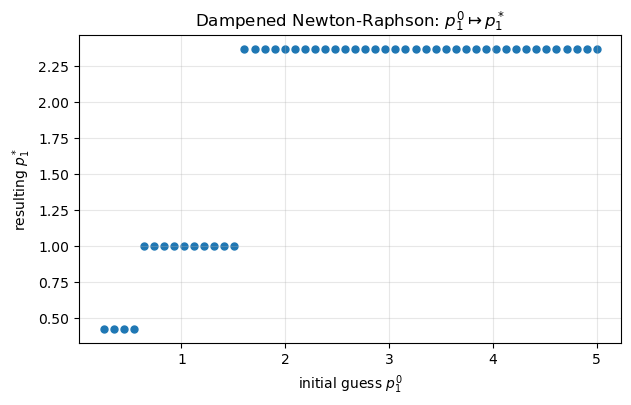

In [49]:
p0_grid = np.linspace(0.25, 5, 50)
pstar = np.array([dampened_newton(p0) for p0 in p0_grid])

plt.figure(figsize=(7,4))
plt.scatter(p0_grid, pstar, s=25)
plt.xlabel(r'initial guess $p_1^0$')
plt.ylabel(r'resulting $p_1^*$')
plt.title('Dampened Newton-Raphson: $p_1^0 \\mapsto p_1^*$')
plt.grid(True, alpha=0.3)
plt.show()

In [50]:
np.unique(np.round(pstar, 3))

array([0.422, 1.   , 2.37 ])

#### Question 2.4 Interpretation

Applying the dampened Newton–Raphson algorithm to a grid of initial prices $p_1^0 \in [0.25, 5]$ reveals the existence of multiple equilibria in the exchange economy.
Depending on the initial guess, the algorithm converges to three distinct equilibrium
prices, approximately $p_1^* = 0.422$, $p_1^* = 1.000$, and $p_1^* = 2.370$.
This demonstrates that while the Newton–Raphson method successfully identifies equilibria,
the equilibrium reached is path-dependent and not all equilibria are found from every
starting value.


### Question 2.5: Equilibrium Allocations in the Edgeworth Box

p1=0.421876 | eps1=-8.18e-09, eps2=3.45e-09


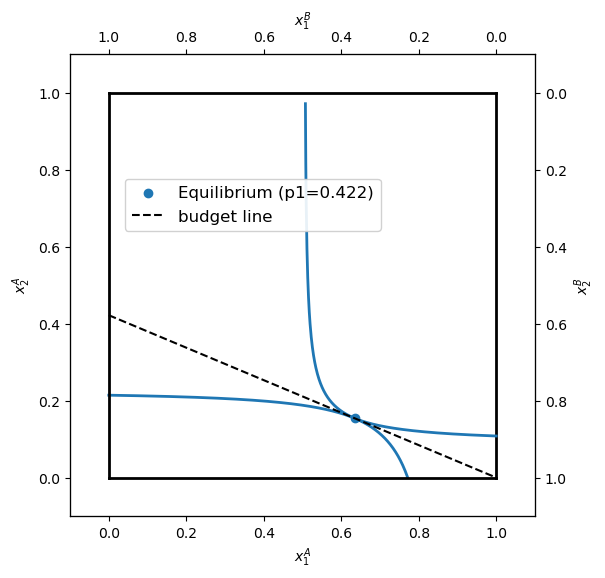

p1=1.000525 | eps1=8.75e-07, eps2=-8.75e-07


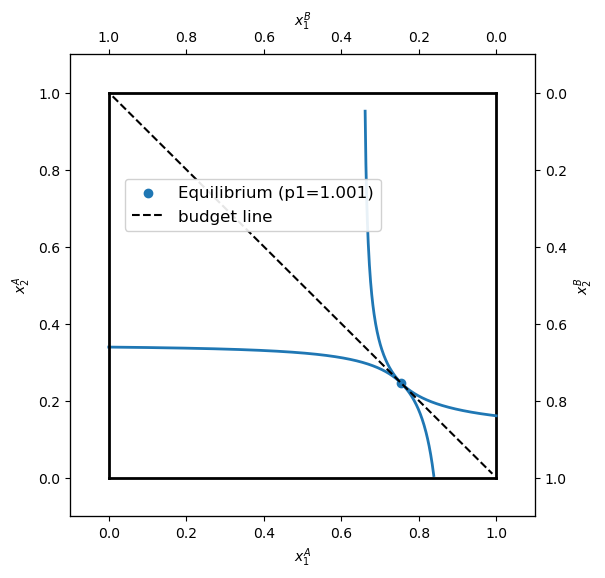

p1=2.370356 | eps1=9.57e-09, eps2=-2.27e-08


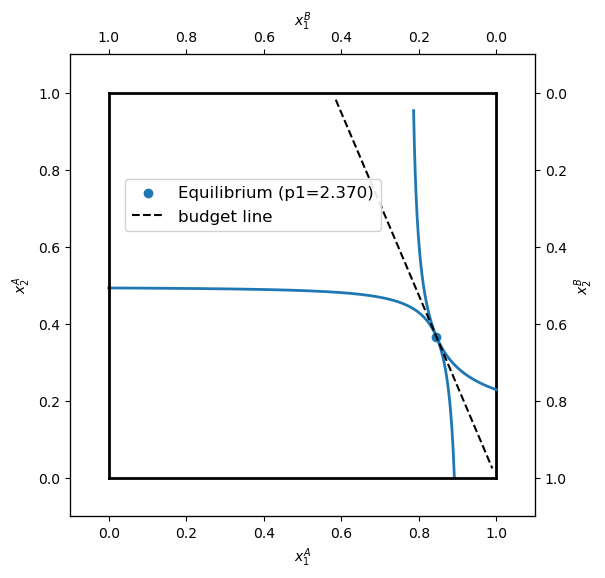

In [51]:
# Replace these with the equilibrium prices you found in Q2.1–Q2.4
pstars = [0.42187627669863426, 1.00052541, 2.3703561473576165] # from Q2.1-Q2.4

for p1 in pstars:

    # compute equilibrium allocations (demands at p1)
    x1A, x2A = model.demand_A(p1)
    x1B, x2B = model.demand_B(p1)

    # sanity check
    eps1, eps2 = model.check_market_clearing(p1)
    print(f"p1={p1:.6f} | eps1={eps1:.2e}, eps2={eps2:.2e}")

    # make Edgeworth box
    fig, axA, axB = model.create_edgeworthbox(figsize=(6,6))

    # plot the allocation point (measured from bottom-left)
    axA.scatter([x1A], [x2A], label=f"Equilibrium (p1={p1:.3f})")

    # plot indifference curves through the equilibrium allocation
    model.indifference_curve_A(axA, x1A, x2A, lw=2)
    model.indifference_curve_B(axB, x1B, x2B, lw=2)

    # plot budget line at that price (needs model.sol.p1)
    model.sol.p1 = p1
    model.plot_budget_line(axA)

    model.add_legend(axA, axB)
    plt.show()

#### Question 2.5 Interpretation

These figures illustrate the equilibrium allocations corresponding to the equilibrium prices identified in Questions 2.1–2.4 using an Edgeworth box representation. Three distinct equilibrium prices are found:  
$p_1^* \approx 0.422$, $p_1^* \approx 1.001$, and $p_1^* \approx 2.370$.

For each equilibrium price, the corresponding consumption bundles for consumers A and B are computed and plotted in the Edgeworth box. At all three equilibria, the indifference curves of the two consumers are tangent at the equilibrium allocation, and the budget line with slope $-p_1^*$ supports the allocation. This confirms that all three equilibria are Pareto efficient and satisfy the first-order optimality conditions

$$
MRS_A = MRS_B = \frac{p_1^*}{p_2}.
$$

Although all three allocations are Walrasian equilibria, the equilibrium near $p_1^* \approx 1.001$ is dynamically unstable, as indicated by the tatonnement and Newton-Raphson algorithms, which converge only to the equilibria near $p_1^* \approx 0.422$ and $p_1^* \approx 2.370$ from generic initial conditions. Nevertheless, the Edgeworth box illustrates that the unstable equilibrium is statically valid and lies on the contract curve.

Overall, the figures demonstrate that the exchange economy admits multiple Pareto-efficient equilibria, each corresponding to a different relative price and allocation of goods between the two consumers.


---

## 3. The AS-AD Model

### Question 3.1: AD–SRAS Equilibrium

In [52]:
import importlib
import ASADModel
importlib.reload(ASADModel)

from ASADModel import ASADModelClass
asad = ASADModelClass()

In [60]:
# parameters from ASADModelClass
# parameters from ASADModelClass (use asad, not model)
par = asad.par

ybar    = par['ybar']
pi_star = par['pi_star']
b       = par['b']
a1      = par['a1']
a2      = par['a2']
gamma   = par['gamma']

# implied parameters/objects
alpha = (b * a1) / (1 + b * a2)

def z_from_v(v):
    return v / (1 + b * a2)

def AD_curve(y, v):
    z = z_from_v(v)
    return pi_star - (1/alpha) * ((y - ybar) - z)

def SRAS_curve(y, pi_e):
    return pi_e + gamma * (y - ybar)

def equilibrium(pi_e, v):
    z = z_from_v(v)
    y_star = ybar + (1 / (1/alpha + gamma)) * ((pi_star - pi_e) + (1/alpha)*z)
    pi_star_t = pi_e + gamma * (y_star - ybar)
    return y_star, pi_star_t

# no demand shock => v=0
y = np.linspace(ybar - 0.25, ybar + 0.25, 400)
v = 0.0

pi_AD = AD_curve(y, v)
pi_SRAS_base = SRAS_curve(y, pi_star)  # pi_e = pi*
pi_SRAS_jump = SRAS_curve(y, 0.08)     # pi_e = 0.08

y_eq_base, pi_eq_base = equilibrium(pi_star, v)
y_eq_jump, pi_eq_jump = equilibrium(0.08, v)

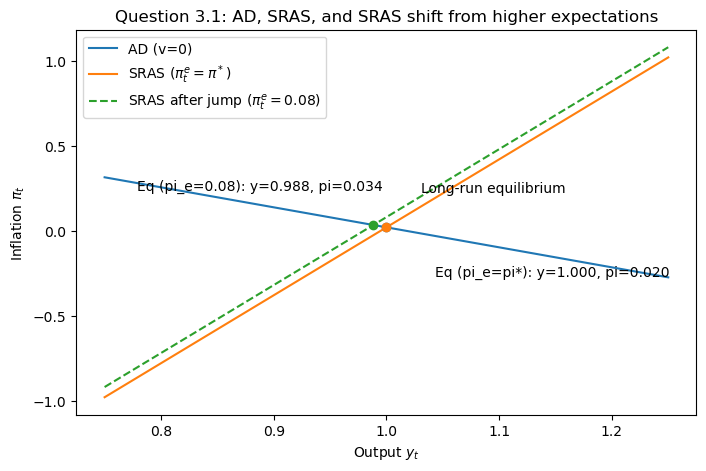

alpha = 0.8490566037735848
Equilibrium when pi_e=pi*: (1.0, 0.02)
Equilibrium when pi_e=0.08: (0.988412017167382, 0.03364806866952812)


In [61]:
# plot
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(y, pi_AD, label='AD (v=0)')
ax.plot(y, pi_SRAS_base, label=r'SRAS ($\pi_t^e=\pi^*$)')
ax.plot(y, pi_SRAS_jump, linestyle='--', label=r'SRAS after jump ($\pi_t^e=0.08$)')

# long-run equilibrium point
ax.scatter([ybar], [pi_star], zorder=5)
ax.annotate('Long-run equilibrium', (ybar, pi_star), xytext=(25, 25), textcoords='offset points')

# intersections
ax.scatter([y_eq_base], [pi_eq_base], zorder=5)
ax.scatter([y_eq_jump], [pi_eq_jump], zorder=5)

ax.annotate(f'Eq (pi_e=pi*): y={y_eq_base:.3f}, pi={pi_eq_base:.3f}',
            (y_eq_base, pi_eq_base),
            xytext=(35, -35), textcoords='offset points')

ax.annotate(f'Eq (pi_e=0.08): y={y_eq_jump:.3f}, pi={pi_eq_jump:.3f}',
            (y_eq_jump, pi_eq_jump),
            xytext=(-170, 25), textcoords='offset points')

ax.set_xlabel('Output $y_t$')
ax.set_ylabel('Inflation $\\pi_t$')
ax.set_title('Question 3.1: AD, SRAS, and SRAS shift from higher expectations')
ax.legend()
plt.show()

print("alpha =", alpha)
print("Equilibrium when pi_e=pi*:", (y_eq_base, pi_eq_base))
print("Equilibrium when pi_e=0.08:", (y_eq_jump, pi_eq_jump))

#### Question 3.1 Interpretation

Figure illustrates the Aggregate Demand (AD) curve, the Short-Run Aggregate Supply (SRAS) curve when inflation expectations are equal to the target, and the long-run equilibrium of the economy. When there is no demand shock ($v_t = 0$) and inflation expectations are anchored at the target ($\pi_t^e = \pi^* = 0.02$), the AD and SRAS curves intersect at the long-run equilibrium. At this point, output equals its natural level, $y_t = \bar{y} = 1$, and inflation equals the target, $\pi_t = \pi^* = 0.02$.

When inflation expectations increase from $\pi_t^e = 0.02$ to $\pi_t^e = 0.08$, the SRAS curve shifts upward in a parallel manner, while the AD curve remains unchanged. Higher expected inflation leads firms to set higher prices for any given level of output. As a result, the new equilibrium occurs at a lower level of output and a higher inflation rate.

The equilibrium implied by the model after the increase in inflation expectations is $y_t^* \approx 0.988$ and $\pi_t^* \approx 0.034$. These values confirm the analytical equilibrium conditions of the AS–AD model when $z_t = 0$. Overall, the figure shows that higher inflation expectations generate a temporary contraction in output and higher inflation, illustrating the short-run trade-off between inflation and output under adaptive expectations.


### Question 3.2: Temporary Demand Shock and Dynamic Adjustment

In [62]:
# Load model (provided file)
from ASADModel import ASADModelClass

model = ASADModelClass()
p = model.par  # parameters dict

# Helper: analytical equilibrium
def equilibrium(pi_e, v, p):
    alpha = p['b'] * p['a1'] / (1.0 + p['b'] * p['a2'])
    z = v / (1.0 + p['b'] * p['a2'])
    inv_alpha = 1.0 / alpha

    D = inv_alpha + p['gamma'] # (1/alpha + gamma)
    B = (p['pi_star'] - pi_e) + inv_alpha * z # bracket term

    y_star = p['ybar'] + (1.0 / D) * B
    pi_star = pi_e + (p['gamma'] / D) * B
    return y_star, pi_star

# Temporary demand shock path: v0=0.1, vt=0 for t>0
T = 5
v = np.zeros(T)
v[0] = 0.1

# Containers
pi_e = np.zeros(T)
y_star = np.zeros(T)
pi_star = np.zeros(T)

# initial expectations
pi_e[0] = p['pi_star']

# Simulate forward period-by-period
for t in range(T):

    # update expectations for t>0
    if t > 0:
        pi_e[t] = p['phi'] * pi_e[t-1] + (1.0 - p['phi']) * pi_star[t-1]

    # equilibrium in period t
    y_star[t], pi_star[t] = equilibrium(pi_e[t], v[t], p)

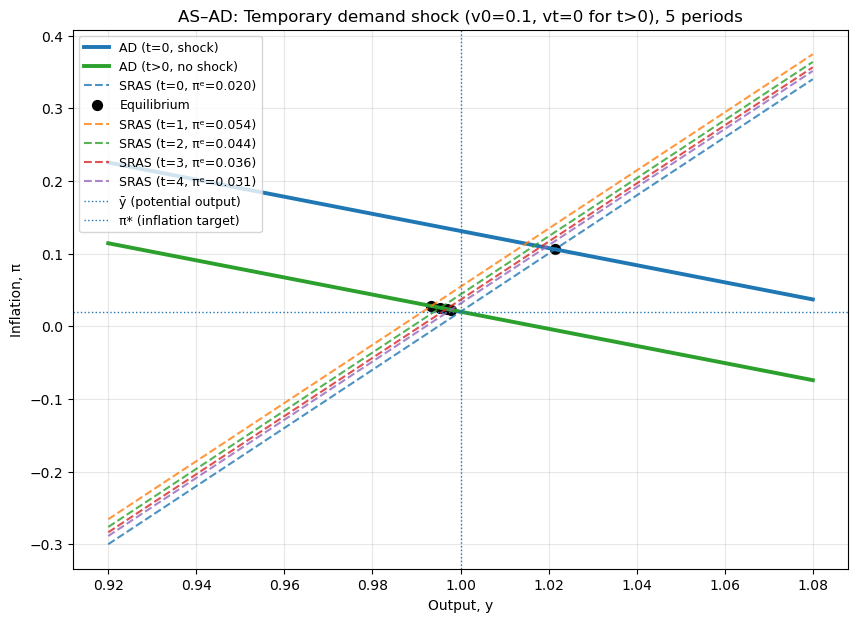

In [63]:
y_grid = np.linspace(p['ybar'] - 0.08, p['ybar'] + 0.08, 400)

plt.figure(figsize=(10, 7))

# AD curves
plt.plot(
    y_grid, model.AD_curve(y_grid, v[0]),
    color="tab:blue", linewidth=2.8, label="AD (t=0, shock)"
)
plt.plot(
    y_grid, model.AD_curve(y_grid, 0.0),
    color="tab:green", linewidth=2.8, label="AD (t>0, no shock)"
)

# SRAS + equilibria
for t in range(T):
    plt.plot(
        y_grid, model.SRAS_curve(y_grid, pi_e[t]),
        linestyle="--", alpha=0.8,
        label=f"SRAS (t={t}, πᵉ={pi_e[t]:.3f})"
    )
    plt.scatter(
        y_star[t], pi_star[t], color="black", s=50,
        label="Equilibrium" if t == 0 else None
    )

# Long-run references
plt.axvline(p['ybar'], linestyle=":", linewidth=1, label="ȳ (potential output)")
plt.axhline(p['pi_star'], linestyle=":", linewidth=1, label="π* (inflation target)")

plt.xlabel("Output, y")
plt.ylabel("Inflation, π")
plt.title("AS–AD: Temporary demand shock (v0=0.1, vt=0 for t>0), 5 periods")
plt.legend(loc="upper left", fontsize=9)
plt.grid(True, alpha=0.3)
plt.show()

#### Question 3.2 Interpretation

This figure illustrates the dynamic effects of a **temporary positive demand shock** in the AS–AD model over **five periods (t = 0,…,4)**. In period **t = 0**, a demand shock of **$v_0 = 0.1$** shifts the AD curve outward, leading to an immediate increase in both output and inflation. Output rises above potential to approximately **$y_0^* \approx 1.02$**, while inflation increases sharply from the target **$\pi^* = 0.02$** to about **$\pi_0^* \approx 0.106$**.

From **t = 1** onward, the demand shock disappears (**$v_t = 0$**), and the AD curve returns immediately to its no-shock position. However, inflation expectations adjust only gradually according to the adaptive expectations rule  
$$
\pi_t^e = \phi \pi_{t-1}^e + (1-\phi)\pi_{t-1}^*,
$$
which causes the SRAS curve to shift upward in period **t = 1** as expectations respond to the high inflation observed in **t = 0**. As a result, output temporarily falls below potential to about **$y_1^* \approx 0.99$**, while inflation declines to **$\pi_1^* \approx 0.028$**, remaining above the target.

In subsequent periods (**t = 2,…,4**), inflation expectations gradually converge back toward the target level, and the SRAS curve shifts downward over time. This leads to a smooth convergence of both output and inflation back to the long-run equilibrium at **$(\bar y, \pi^*) = (1, 0.02)$**. Overall, the analysis highlights the asymmetry between **instantaneous demand adjustment** and **gradual expectation-driven supply adjustment**, which generates short-run overshooting in inflation and a temporary output gap following a transitory demand shock.


### Question 3.3: Persistent Stochastic Demand Shocks in the AS–AD Model

In [64]:
# Set up model + parameters
model = ASADModelClass()
p = model.par

T = 500
sigma_eps = 0.01
seed = 123

def alpha_and_z(v, p):
    alpha = p['b'] * p['a1'] / (1.0 + p['b'] * p['a2'])
    z = v / (1.0 + p['b'] * p['a2'])
    return alpha, z

def equilibrium(pi_e, v, p):
    """
    Analytical equilibrium from exam formulas (10)-(11), with z_t implied by v_t.
    Returns (y_star, pi_star).
    """
    alpha, z = alpha_and_z(v, p)
    inv_alpha = 1.0 / alpha
    denom = inv_alpha + p['gamma']

    bracket = (p['pi_star'] - pi_e) + inv_alpha * z
    y_star = p['ybar'] + (1.0 / denom) * bracket
    pi_star = pi_e + p['gamma'] * (y_star - p['ybar'])
    return y_star, pi_star

def simulate_asad_ar1(rho, eps_draws, p):
    """
    Simulate for t=0,...,T-1 with:
      pi_e0 = pi_star
      pi_e_t = phi*pi_e_{t-1} + (1-phi)*pi_star_{t-1} for t>0
      v_t = rho*v_{t-1} + eps_t, with v_{-1}=0
    """
    T = len(eps_draws)

    y = np.empty(T)
    pi = np.empty(T)
    v = np.empty(T)
    pi_e = np.empty(T)

    # initial conditions
    pi_e[0] = p['pi_star']
    v_prev = 0.0  # v_{-1} = 0

    for t in range(T):
        if t > 0:
            pi_e[t] = p['phi'] * pi_e[t-1] + (1.0 - p['phi']) * pi[t-1]

        v[t] = rho * v_prev + eps_draws[t]
        v_prev = v[t]

        y[t], pi[t] = equilibrium(pi_e[t], v[t], p)

    return y, pi, v, pi_e

def moments(y, pi):
    sd_y = np.std(y, ddof=1)
    sd_pi = np.std(pi, ddof=1)
    corr = np.corrcoef(y, pi)[0, 1]
    return sd_y, sd_pi, corr

rho = 0.80
sd(y*)  = 0.002704
sd(pi*) = 0.016825
corr(y*, pi*) = 0.514254


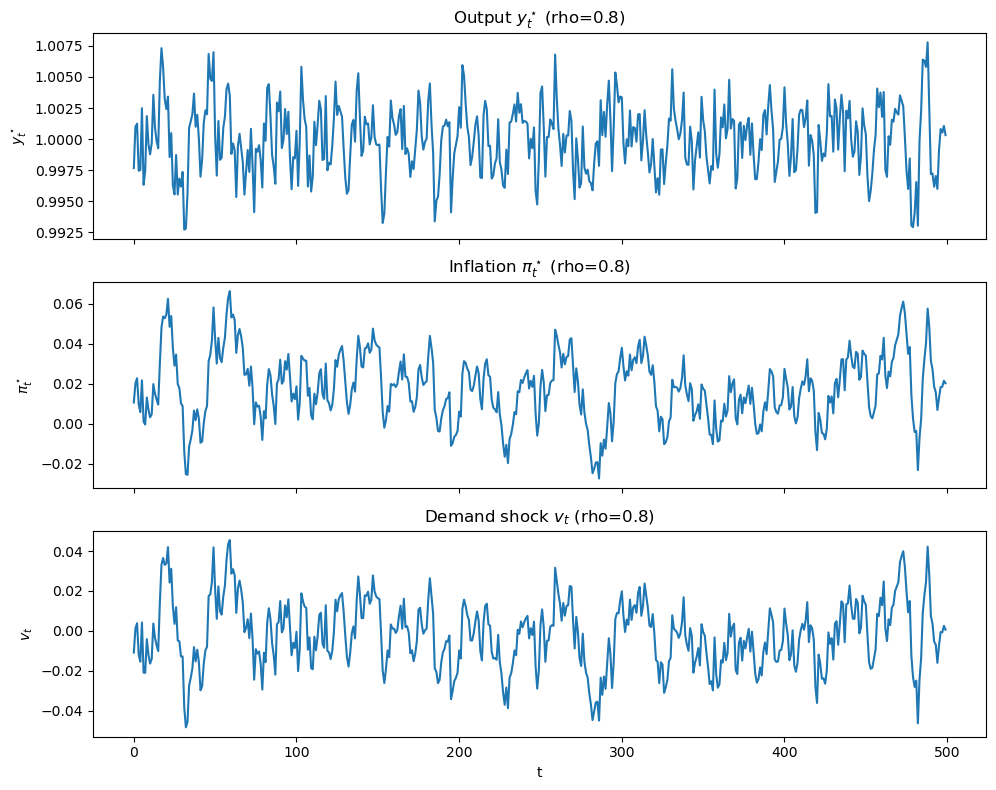

In [65]:
# Draw shocks one time
np.random.seed(seed)
eps = np.random.normal(loc=0.0, scale=sigma_eps, size=T)

# Simulate for rho = 0.8 
rho1 = 0.80
y1, pi1, v1, pie1 = simulate_asad_ar1(rho1, eps, p)
sd_y1, sd_pi1, corr1 = moments(y1, pi1)

print(f"rho = {rho1:.2f}")
print(f"sd(y*)  = {sd_y1:.6f}")
print(f"sd(pi*) = {sd_pi1:.6f}")
print(f"corr(y*, pi*) = {corr1:.6f}")

fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
ax[0].plot(y1)
ax[0].set_title(f"Output $y_t^\\star$ (rho={rho1})")
ax[0].set_ylabel("$y_t^\\star$")

ax[1].plot(pi1)
ax[1].set_title(f"Inflation $\\pi_t^\\star$ (rho={rho1})")
ax[1].set_ylabel("$\\pi_t^\\star$")

ax[2].plot(v1)
ax[2].set_title(f"Demand shock $v_t$ (rho={rho1})")
ax[2].set_ylabel("$v_t$")
ax[2].set_xlabel("t")

plt.tight_layout()
plt.show()


rho = 0.50
sd(y*)  = 0.002396
sd(pi*) = 0.010940
corr(y*, pi*) = 0.700982


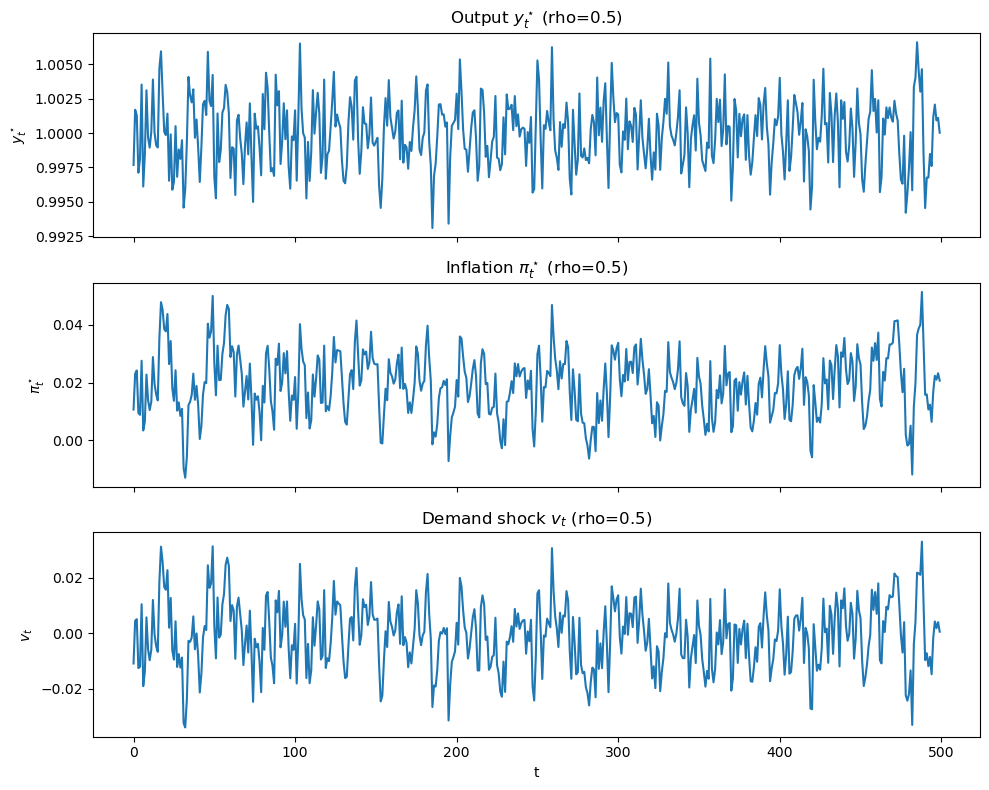

In [66]:
# Repeat for rho = 0.5 (same eps)
rho2 = 0.50
y2, pi2, v2, pie2 = simulate_asad_ar1(rho2, eps, p)
sd_y2, sd_pi2, corr2 = moments(y2, pi2)

print(f"\nrho = {rho2:.2f}")
print(f"sd(y*)  = {sd_y2:.6f}")
print(f"sd(pi*) = {sd_pi2:.6f}")
print(f"corr(y*, pi*) = {corr2:.6f}")

fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
ax[0].plot(y2)
ax[0].set_title(f"Output $y_t^\\star$ (rho={rho2})")
ax[0].set_ylabel("$y_t^\\star$")

ax[1].plot(pi2)
ax[1].set_title(f"Inflation $\\pi_t^\\star$ (rho={rho2})")
ax[1].set_ylabel("$\\pi_t^\\star$")

ax[2].plot(v2)
ax[2].set_title(f"Demand shock $v_t$ (rho={rho2})")
ax[2].set_ylabel("$v_t$")
ax[2].set_xlabel("t")

plt.tight_layout()
plt.show()

#### Question 3.3 Interpretation 

This question analyzes the dynamic behavior of output and inflation when aggregate demand is subject to **persistent stochastic shocks**. The demand shock follows an AR(1) process,
$$
v_t = \rho v_{t-1} + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0, \sigma_\varepsilon),
$$
with $\sigma_\varepsilon = 0.01$ and adaptive inflation expectations. The model is simulated for $T=500$ periods with initial expectations $\pi^e_0=\pi^*$.

---

##### Case 1: High persistence ($\rho = 0.80$)

With highly persistent demand shocks, both output and inflation exhibit **sustained deviations** from their long-run targets.

- The standard deviation of output is $\text{sd}(y_t^*) = 0.002704$, indicating moderate but persistent output fluctuations around $\bar y = 1$.
- Inflation is substantially more volatile, with $\text{sd}(\pi_t^*) = 0.016825$, reflecting the steep slope of the SRAS curve and adaptive expectations.
- The correlation between output and inflation is positive, $\text{corr}(y_t^*, \pi_t^*) = 0.514$, consistent with demand-driven fluctuations.

The time-series plots show smooth and persistent movements in $v_t$, which translate into prolonged deviations of both $y_t^*$ and $\pi_t^*$ from their steady-state values. This highlights how **high shock persistence amplifies macroeconomic volatility**.

---

##### Case 2: Lower persistence ($\rho = 0.50$)

When demand shocks are less persistent, macroeconomic fluctuations become **smaller and shorter-lived**.

- Output volatility falls to $\text{sd}(y_t^*) = 0.002396$.
- Inflation volatility declines markedly to $\text{sd}(\pi_t^*) = 0.010940$.
- The correlation between output and inflation increases to $\text{corr}(y_t^*, \pi_t^*) = 0.701$.

The demand shocks now revert more quickly toward zero, leading to faster stabilization of both output and inflation. As a result, movements in $y_t^*$ and $\pi_t^*$ are more synchronized in the short run, explaining the higher contemporaneous correlation.

---

##### Key insight

Comparing the two cases shows that **greater persistence in demand shocks ($\rho$)** leads to:
- Higher volatility in both output and inflation,
- More prolonged deviations from long-run equilibrium,
- Weaker contemporaneous correlation between output and inflation.

Overall, this simulation illustrates how the persistence of demand shocks is a crucial determinant of macroeconomic volatility in the AS–AD model with adaptive expectations.
